In [ ]:
import cosmic.utils as cu
from galaxyClf_xgb import GalaxyXGBInference
import numpy as np
import matplotlib.pyplot as plt

model_dir = './LSDR10/grzW1W2/2NoSpec_xSpec_NoErr'
inference = GalaxyXGBInference(model_dir)

In [45]:
data_path = '/home/tiandc/Data/LegacySurveys/DR9x10_Gaia/raw72/lsdr9x10_01.fits'
df = cu.readfile(data_path)

# 计算 mag_Err（模型需要）
def snr_to_error(snr):
    return 2.5 / np.log(10) / snr

df['mag_g_Err'] = snr_to_error(df['snr_g'])
df['mag_r_Err'] = snr_to_error(df['snr_r'])
df['mag_z_Err'] = snr_to_error(df['snr_z'])
df['mag_w1_Err'] = snr_to_error(df['snr_w1'])
df['mag_w2_Err'] = snr_to_error(df['snr_w2'])

df['bp_g'] = df['gaia_phot_bp_mean_mag'] - df['gaia_phot_g_mean_mag']
df['g_rp'] = df['gaia_phot_g_mean_mag'] - df['gaia_phot_rp_mean_mag']

In [46]:
_, pred_proba = inference.predict(df)
df['pred_proba'] = pred_proba
print(f"预测完成，共 {len(df)} 行")
print(f"预测为星系 (prob >= 0.5): {(pred_proba >= 0.5).sum()}")
print(f"预测为非星系 (prob < 0.5): {(pred_proba < 0.5).sum()}")

预测完成，共 17531326 行
预测为星系 (prob >= 0.5): 4737072
预测为非星系 (prob < 0.5): 12794254


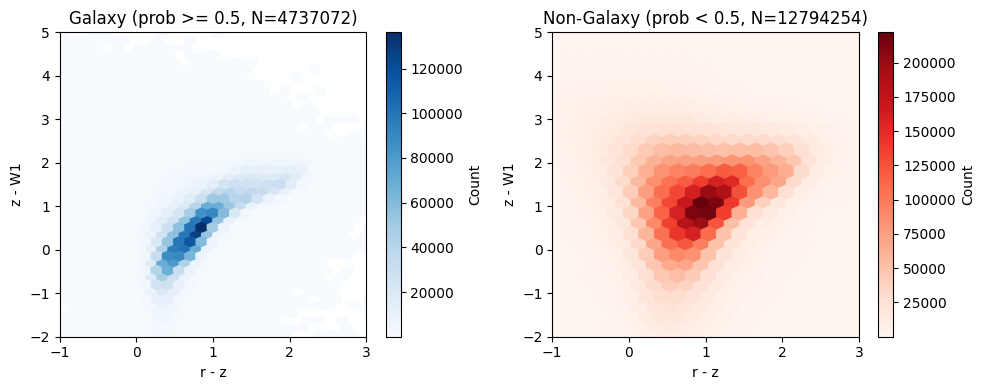

In [47]:
# Use hexbin instead of scatter (better for large datasets)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Left: Galaxy (prob >= 0.5)
galaxy_mask = df['pred_proba'] >= 0.5
ax = axes[0]
hb = ax.hexbin(df.loc[galaxy_mask, 'r_z'], df.loc[galaxy_mask, 'z_w1'],
               gridsize=100, cmap='Blues', mincnt=1)
plt.colorbar(hb, ax=ax, label='Count')
ax.set_xlabel('r - z')
ax.set_ylabel('z - W1')
ax.set_title(f'Galaxy (prob >= 0.5, N={galaxy_mask.sum()})')
ax.set_xlim(-1, 3)
ax.set_ylim(-2, 5)

# Right: Non-Galaxy (prob < 0.5)
star_mask = df['pred_proba'] < 0.5
ax = axes[1]
hb = ax.hexbin(df.loc[star_mask, 'r_z'], df.loc[star_mask, 'z_w1'],
               gridsize=100, cmap='Reds', mincnt=1)
plt.colorbar(hb, ax=ax, label='Count')
ax.set_xlabel('r - z')
ax.set_ylabel('z - W1')
ax.set_title(f'Non-Galaxy (prob < 0.5, N={star_mask.sum()})')
ax.set_xlim(-1, 3)
ax.set_ylim(-2, 5)

plt.tight_layout()
plt.show()

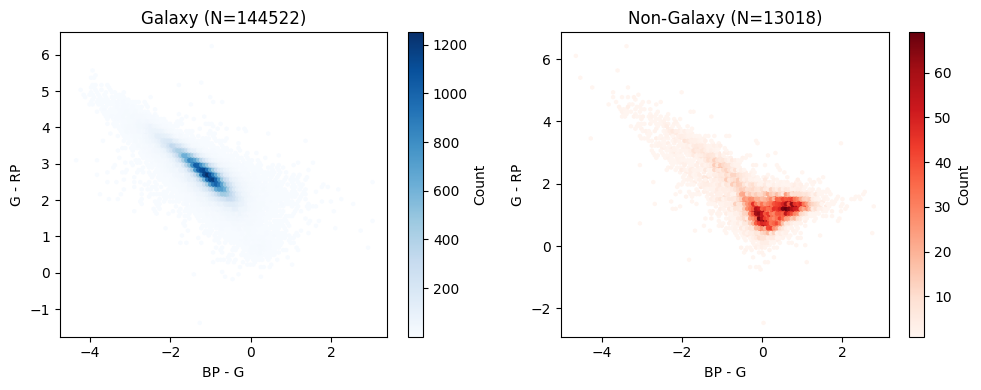

In [48]:
# BP-G vs G-RP (Gaia colors)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
mask = (df['gaia_phot_bp_mean_mag'] > 0) & (df['gaia_phot_rp_mean_mag'] > 0)

# Left: Galaxy
galaxy_gaia = mask & (df['pred_proba'] >= 0.5)
ax = axes[0]
hb = ax.hexbin(df.loc[galaxy_gaia, 'bp_g'], df.loc[galaxy_gaia, 'g_rp'],
               gridsize=100, cmap='Blues', mincnt=1)
plt.colorbar(hb, ax=ax, label='Count')
ax.set_xlabel('BP - G')
ax.set_ylabel('G - RP')
ax.set_title(f'Galaxy (N={galaxy_gaia.sum()})')

# Right: Non-Galaxy
star_gaia = mask & (df['pred_proba'] < 0.5)
ax = axes[1]
hb = ax.hexbin(df.loc[star_gaia, 'bp_g'], df.loc[star_gaia, 'g_rp'],
               gridsize=100, cmap='Reds', mincnt=1)
plt.colorbar(hb, ax=ax, label='Count')
ax.set_xlabel('BP - G')
ax.set_ylabel('G - RP')
ax.set_title(f'Non-Galaxy (N={star_gaia.sum()})')

plt.tight_layout()
plt.show()

In [49]:
# Proper motion analysis
# Filter sources with valid Gaia photometry (to exclude sources without Gaia data)
has_gaia = df['gaia_phot_g_mean_mag'] > 0
print(f"Sources with Gaia photometry: {has_gaia.sum()} / {len(df)}")

# Calculate total proper motion (mas/yr)
df['pm_total'] = np.sqrt(df['pmra']**2 + df['pmdec']**2)

# Define PM threshold (significant PM -> likely star)
PM_THRESHOLD = 3.0  # mas/yr

# Only analyze sources with valid Gaia data
pm_low = has_gaia & (df['pm_total'] < PM_THRESHOLD)   # PM < 3
pm_high = has_gaia & (df['pm_total'] >= PM_THRESHOLD)  # PM >= 3 (likely stars)

print(f"\nPM selection for Gaia sources (threshold = {PM_THRESHOLD} mas/yr):")
print(f"  PM < {PM_THRESHOLD}: {pm_low.sum()}")
print(f"  PM >= {PM_THRESHOLD} (Star): {pm_high.sum()}")

Sources with Gaia photometry: 158702 / 17531326

PM selection for Gaia sources (threshold = 3.0 mas/yr):
  PM < 3.0: 152358
  PM >= 3.0 (Star): 6344


In [50]:
# Compare XGB prediction vs PM selection (only for sources with Gaia data)
xgb_galaxy = df['pred_proba'] >= 0.5
xgb_star = df['pred_proba'] < 0.5

# Cross-tabulation (only Gaia sources)
print("=" * 60)
print("XGB Prediction vs PM Selection (Gaia sources only)")
print("=" * 60)
print(f"Total Gaia sources: {has_gaia.sum()}")
print(f"                      | PM<3       | PM>=3 Star |")
print(f"XGB=Galaxy (prob>=0.5)| {(xgb_galaxy & pm_low).sum():>10} | {(xgb_galaxy & pm_high).sum():>10} |")
print(f"XGB=Non-Gal (prob<0.5)| {(xgb_star & pm_low).sum():>10} | {(xgb_star & pm_high).sum():>10} |")

# Agreement analysis (only Gaia sources)
agree = ((xgb_galaxy & pm_low) | (xgb_star & pm_high)).sum()
total_gaia = has_gaia.sum()
print(f"\nAgreement rate (Gaia): {agree}/{total_gaia} = {agree/total_gaia*100:.2f}%")

# Key: XGB rejects but PM low (among Gaia sources)
xgb_reject_pm_low = xgb_star & pm_low
print(f"\nXGB rejects but PM<3: {xgb_reject_pm_low.sum()}")
print("  (Possibly distant stars with insignificant PM)")

# Sources without Gaia data
no_gaia = ~has_gaia
print(f"\nSources without Gaia data: {no_gaia.sum()}")
print(f"  XGB=Galaxy: {(xgb_galaxy & no_gaia).sum()}")
print(f"  XGB=Non-Galaxy: {(xgb_star & no_gaia).sum()}")

XGB Prediction vs PM Selection (Gaia sources only)
Total Gaia sources: 158702
                      | PM<3       | PM>=3 Star |
XGB=Galaxy (prob>=0.5)|     143767 |       1398 |
XGB=Non-Gal (prob<0.5)|       8591 |       4946 |

Agreement rate (Gaia): 148713/158702 = 93.71%

XGB rejects but PM<3: 8591
  (Possibly distant stars with insignificant PM)

Sources without Gaia data: 17372624
  XGB=Galaxy: 4591907
  XGB=Non-Galaxy: 12780717


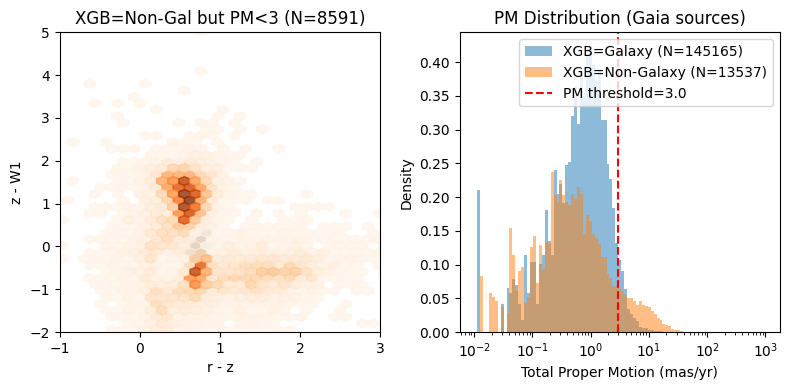

In [51]:
# Visualization: XGB rejected but PM<3 sources (Gaia sources only)
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# Left: r-z vs z-W1
ax = axes[0]
# Background: all Gaia sources
ax.hexbin(df.loc[has_gaia, 'r_z'], df.loc[has_gaia, 'z_w1'], 
          gridsize=80, cmap='Greys', mincnt=1, alpha=0.5)
# Foreground: XGB rejected but PM<3
if xgb_reject_pm_low.sum() > 0:
    ax.hexbin(df.loc[xgb_reject_pm_low, 'r_z'], df.loc[xgb_reject_pm_low, 'z_w1'],
              gridsize=80, cmap='Oranges', mincnt=1, alpha=0.8)
ax.set_xlabel('r - z')
ax.set_ylabel('z - W1')
ax.set_title(f'XGB=Non-Gal but PM<3 (N={xgb_reject_pm_low.sum()})')
ax.set_xlim(-1, 3)
ax.set_ylim(-2, 5)

# Right: PM distribution comparison (Gaia sources only)
ax = axes[1]
bins = np.logspace(-2, 3, 100)
ax.hist(df.loc[xgb_galaxy & has_gaia, 'pm_total'], bins=bins, alpha=0.5, 
        label=f'XGB=Galaxy (N={(xgb_galaxy & has_gaia).sum()})', density=True)
ax.hist(df.loc[xgb_star & has_gaia, 'pm_total'], bins=bins, alpha=0.5,
        label=f'XGB=Non-Galaxy (N={(xgb_star & has_gaia).sum()})', density=True)
ax.axvline(PM_THRESHOLD, color='red', linestyle='--', label=f'PM threshold={PM_THRESHOLD}')
ax.set_xscale('log')
ax.set_xlabel('Total Proper Motion (mas/yr)')
ax.set_ylabel('Density')
ax.set_title('PM Distribution (Gaia sources)')
ax.legend()

plt.tight_layout()
plt.show()

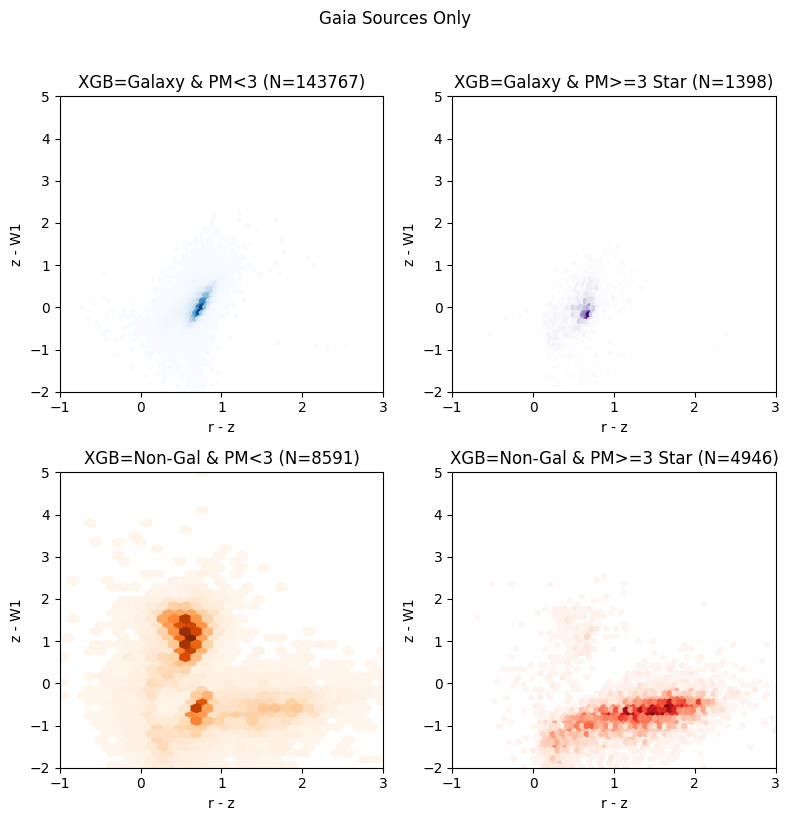

In [52]:
# 4-quadrant color-color plot: XGB x PM classification (Gaia sources only)
fig, axes = plt.subplots(2, 2, figsize=(8, 8))

categories = [
    (xgb_galaxy & pm_low,  'XGB=Galaxy & PM<3', 'Blues'),
    (xgb_galaxy & pm_high, 'XGB=Galaxy & PM>=3 Star', 'Purples'),
    (xgb_star & pm_low,    'XGB=Non-Gal & PM<3', 'Oranges'),
    (xgb_star & pm_high,   'XGB=Non-Gal & PM>=3 Star', 'Reds'),
]

for ax, (mask, title, cmap) in zip(axes.flat, categories):
    n = mask.sum()
    if n > 0:
        ax.hexbin(df.loc[mask, 'r_z'], df.loc[mask, 'z_w1'],
                  gridsize=80, cmap=cmap, mincnt=1)
    ax.set_xlabel('r - z')
    ax.set_ylabel('z - W1')
    ax.set_title(f'{title} (N={n})')
    ax.set_xlim(-1, 3)
    ax.set_ylim(-2, 5)

plt.suptitle('Gaia Sources Only', y=1.02)
plt.tight_layout()
plt.show()

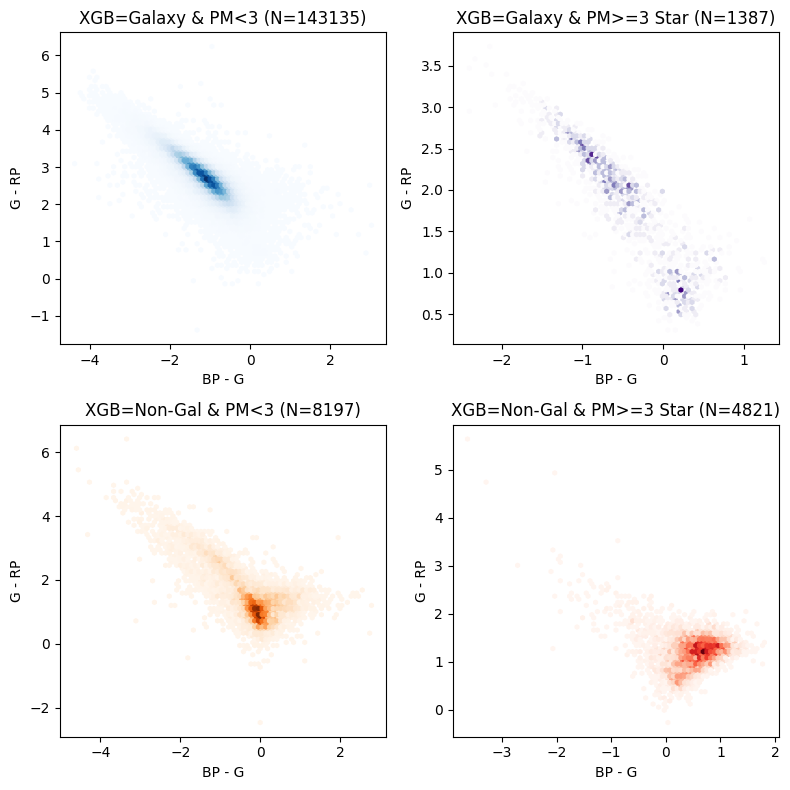

In [53]:
# Gaia color plot: 4-quadrant comparison
fig, axes = plt.subplots(2, 2, figsize=(8, 8))
gaia_mask = (df['gaia_phot_bp_mean_mag'] > 0) & (df['gaia_phot_rp_mean_mag'] > 0)

categories = [
    (xgb_galaxy & pm_low & gaia_mask,  'XGB=Galaxy & PM<3', 'Blues'),
    (xgb_galaxy & pm_high & gaia_mask, 'XGB=Galaxy & PM>=3 Star', 'Purples'),
    (xgb_star & pm_low & gaia_mask,    'XGB=Non-Gal & PM<3', 'Oranges'),
    (xgb_star & pm_high & gaia_mask,   'XGB=Non-Gal & PM>=3 Star', 'Reds'),
]

for ax, (mask, title, cmap) in zip(axes.flat, categories):
    n = mask.sum()
    if n > 0:
        ax.hexbin(df.loc[mask, 'bp_g'], df.loc[mask, 'g_rp'],
                  gridsize=80, cmap=cmap, mincnt=1)
    ax.set_xlabel('BP - G')
    ax.set_ylabel('G - RP')
    ax.set_title(f'{title} (N={n})')

plt.tight_layout()
plt.show()

PM>=3 Star but XGB=Galaxy: 1398


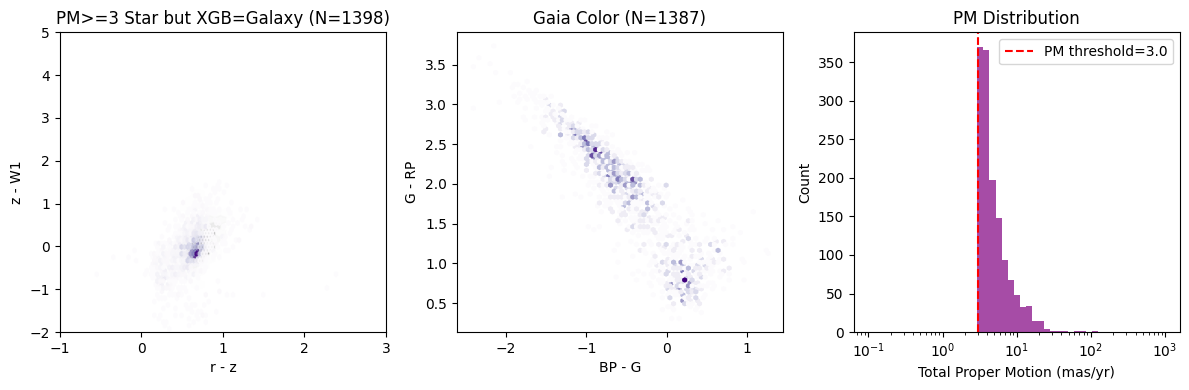


Statistics for PM>=3 Star but XGB=Galaxy:
  Median PM: 4.17 mas/yr
  Mean pred_proba: 0.901


In [54]:
# Check sources with PM>=3 (Star) but XGB=Galaxy
xgb_keep_pm_star = xgb_galaxy & pm_high
print(f"PM>=3 Star but XGB=Galaxy: {xgb_keep_pm_star.sum()}")

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Left: r-z vs z-W1
ax = axes[0]
ax.hexbin(df.loc[has_gaia, 'r_z'], df.loc[has_gaia, 'z_w1'], 
          gridsize=80, cmap='Greys', mincnt=1, alpha=0.5)
if xgb_keep_pm_star.sum() > 0:
    ax.hexbin(df.loc[xgb_keep_pm_star, 'r_z'], df.loc[xgb_keep_pm_star, 'z_w1'],
              gridsize=80, cmap='Purples', mincnt=1, alpha=0.8)
ax.set_xlabel('r - z')
ax.set_ylabel('z - W1')
ax.set_title(f'PM>=3 Star but XGB=Galaxy (N={xgb_keep_pm_star.sum()})')
ax.set_xlim(-1, 3)
ax.set_ylim(-2, 5)

# Middle: BP-G vs G-RP
ax = axes[1]
gaia_color_mask = (df['gaia_phot_bp_mean_mag'] > 0) & (df['gaia_phot_rp_mean_mag'] > 0)
mask_plot = xgb_keep_pm_star & gaia_color_mask
if mask_plot.sum() > 0:
    ax.hexbin(df.loc[mask_plot, 'bp_g'], df.loc[mask_plot, 'g_rp'],
              gridsize=80, cmap='Purples', mincnt=1)
ax.set_xlabel('BP - G')
ax.set_ylabel('G - RP')
ax.set_title(f'Gaia Color (N={mask_plot.sum()})')

# Right: PM distribution
ax = axes[2]
bins = np.logspace(-1, 3, 50)
ax.hist(df.loc[xgb_keep_pm_star, 'pm_total'], bins=bins, alpha=0.7, color='purple')
ax.axvline(PM_THRESHOLD, color='red', linestyle='--', label=f'PM threshold={PM_THRESHOLD}')
ax.set_xscale('log')
ax.set_xlabel('Total Proper Motion (mas/yr)')
ax.set_ylabel('Count')
ax.set_title('PM Distribution')
ax.legend()

plt.tight_layout()
plt.show()

# Statistics
print(f"\nStatistics for PM>=3 Star but XGB=Galaxy:")
print(f"  Median PM: {df.loc[xgb_keep_pm_star, 'pm_total'].median():.2f} mas/yr")
print(f"  Mean pred_proba: {df.loc[xgb_keep_pm_star, 'pred_proba'].mean():.3f}")

In [60]:
idx = xgb_galaxy & pm_high
idx &= df['pred_proba'] > 0.9
df[idx].sort_values(by='fracflux_r', ascending=False)[
    ['ra','dec','pred_proba', 'pm_total', 'fracflux_r', 'fracin_r', 'fracmasked_r']]

,ra,dec,pred_proba,pm_total,fracflux_r,fracin_r,fracmasked_r
13959983,9.306849,8.207592,0.990961,14.740356,53.035198,0.664683,0.560949
14389981,5.732047,11.458509,0.957518,3.675309,39.551266,0.869126,0.604748
2434639,5.060215,-51.715328,0.995230,8.537207,17.619551,1.000000,0.656118
3577187,6.742703,-84.005858,0.982700,6.265209,8.135039,0.999914,0.000415
186966,6.727506,-69.224611,0.987905,19.515261,7.830184,1.000000,0.221109
...,...,...,...,...,...,...,...
16349406,9.120712,25.442256,0.994285,3.431080,0.000000,0.999130,0.002640
17307189,8.409628,32.573327,0.987572,6.194519,0.000000,0.998889,0.002438
398164,7.872291,-66.715393,0.993321,4.401907,0.000000,0.997778,0.017983
17345520,5.812965,32.926967,0.990683,4.443615,0.000000,0.997798,0.003546


In [ ]:
tab = df[df['pred_proba'] > 0.6].sort_values(by='pred_proba', ascending=True)[
        ['ra','dec','pred_proba', 'pm_total', 'fracflux_r', 'fracin_r', 'fracmasked_r']].head(100)

In [57]:
tab.iloc[[97]]

,ra,dec,pred_proba,pm_total,fracflux_r,fracin_r,fracmasked_r
233421,9.358374,-68.677586,0.600048,0.0,0.005241,1.0,0.010425


In [58]:
tab[['ra','dec']].to_csv('check.csv', index=False)

# 用光谱样本测试

- NoSpec模型

In [1]:
import cosmic.utils as cu
from galaxyClf_xgb import GalaxyXGBInference
import numpy as np
import matplotlib.pyplot as plt

model_dir = './LSDR10/grzW1W2/1NoSpec'
inference = GalaxyXGBInference(model_dir)

path = '../data/LSDR10/LSDR10.fits'
df = cu.readfile(path)
print('galaxy: ', df[df['label'] == 1].shape[0])
print('star&QSO: ', df[df['label'] == 0].shape[0])

_, pred_proba = inference.predict(df)
df['pred_proba'] = pred_proba
print(f"预测完成，共 {len(df)} 行")
print(f"预测为星系 (prob >= 0.5): {(pred_proba >= 0.5).sum()}")
print(f"预测为非星系 (prob < 0.5): {(pred_proba < 0.5).sum()}")

galaxy:  2990176
star&QSO:  2990176
预测完成，共 5980352 行
预测为星系 (prob >= 0.5): 3143733
预测为非星系 (prob < 0.5): 2836619


Accuracy: 95.60%
Galaxy recall (TP / (TP+FN)): 98.16%
Galaxy precision (TP / (TP+FP)): 93.37%
Star/QSO recall (TN / (TN+FP)): 93.03%
Star/QSO precision (TN / (TN+FN)): 98.07%
点源对星系的污染率 (FP/(TP+FP)): 6.63%
星系对点源的污染率 (FN/(TN+FN)): 1.93%


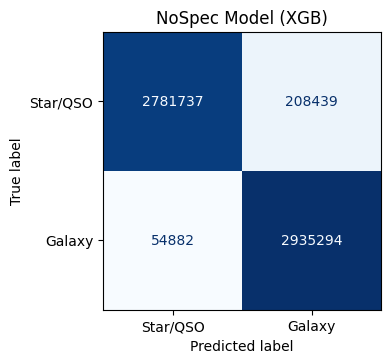

In [2]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

pred = (df['pred_proba'] >= 0.5).astype(int)
cm = confusion_matrix(df['label'], pred)

# Print rates
tn, fp, fn, tp = cm.ravel()
accuracy = (tp + tn) / (tp + tn + fp + fn)
print(f"Accuracy: {accuracy*100:.2f}%")
print(f"Galaxy recall (TP / (TP+FN)): {tp/(tp+fn)*100:.2f}%")
print(f"Galaxy precision (TP / (TP+FP)): {tp/(tp+fp)*100:.2f}%")
print(f"Star/QSO recall (TN / (TN+FP)): {tn/(tn+fp)*100:.2f}%")
print(f"Star/QSO precision (TN / (TN+FN)): {tn/(tn+fn)*100:.2f}%")

# 污染率
print(f"点源对星系的污染率 (FP/(TP+FP)): {fp/(tp+fp)*100:.2f}%")
print(f"星系对点源的污染率 (FN/(TN+FN)): {fn/(tn+fn)*100:.2f}%")

fig, ax = plt.subplots(figsize=(4, 4))
disp = ConfusionMatrixDisplay(cm, display_labels=['Star/QSO', 'Galaxy'])
disp.plot(ax=ax, cmap='Blues', values_format='d', colorbar=False)
ax.set_title('NoSpec Model (XGB)')
plt.tight_layout()
plt.show()

- NoSpec_NoErr模型

In [3]:
import cosmic.utils as cu
from galaxyClf_xgb import GalaxyXGBInference
import numpy as np
import matplotlib.pyplot as plt

model_dir = './LSDR10/grzW1W2/1NoSpec_NoErr'
inference = GalaxyXGBInference(model_dir)

path = '../data/LSDR10/LSDR10.fits'
df = cu.readfile(path)
print('galaxy: ', df[df['label'] == 1].shape[0])
print('star&QSO: ', df[df['label'] == 0].shape[0])

_, pred_proba = inference.predict(df)
df['pred_proba'] = pred_proba
print(f"预测完成，共 {len(df)} 行")
print(f"预测为星系 (prob >= 0.5): {(pred_proba >= 0.5).sum()}")
print(f"预测为非星系 (prob < 0.5): {(pred_proba < 0.5).sum()}")

galaxy:  2990176
star&QSO:  2990176
预测完成，共 5980352 行
预测为星系 (prob >= 0.5): 3200167
预测为非星系 (prob < 0.5): 2780185


Accuracy: 95.10%
Galaxy recall (TP / (TP+FN)): 98.62%
Galaxy precision (TP / (TP+FP)): 92.14%
Star/QSO recall (TN / (TN+FP)): 91.59%
Star/QSO precision (TN / (TN+FN)): 98.51%
点源对星系的污染率 (FP/(TP+FP)): 7.86%
星系对点源的污染率 (FN/(TN+FN)): 1.49%


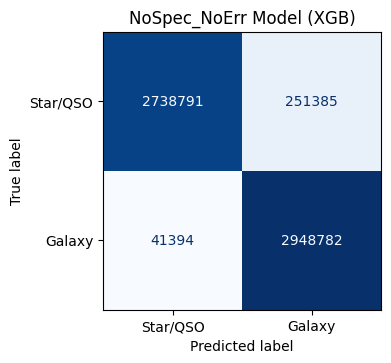

In [4]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

pred = (df['pred_proba'] >= 0.5).astype(int)
cm = confusion_matrix(df['label'], pred)

# Print rates
tn, fp, fn, tp = cm.ravel()
accuracy = (tp + tn) / (tp + tn + fp + fn)
print(f"Accuracy: {accuracy*100:.2f}%")
print(f"Galaxy recall (TP / (TP+FN)): {tp/(tp+fn)*100:.2f}%")
print(f"Galaxy precision (TP / (TP+FP)): {tp/(tp+fp)*100:.2f}%")
print(f"Star/QSO recall (TN / (TN+FP)): {tn/(tn+fp)*100:.2f}%")
print(f"Star/QSO precision (TN / (TN+FN)): {tn/(tn+fn)*100:.2f}%")

# 污染率
print(f"点源对星系的污染率 (FP/(TP+FP)): {fp/(tp+fp)*100:.2f}%")
print(f"星系对点源的污染率 (FN/(TN+FN)): {fn/(tn+fn)*100:.2f}%")

fig, ax = plt.subplots(figsize=(4, 4))
disp = ConfusionMatrixDisplay(cm, display_labels=['Star/QSO', 'Galaxy'])
disp.plot(ax=ax, cmap='Blues', values_format='d', colorbar=False)
ax.set_title('NoSpec_NoErr Model (XGB)')
plt.tight_layout()
plt.show()

# 小结
- 使用grzW1W2波段预测，能够保留大部分星系，同时排除大量点源。
- 可以设置 `fracflux_r > 1`，确保曝光正常。
- 结合机器学习和GAIA自行应该能排除大量点源